In [1]:
!pip install wfdb nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import nltk
from collections import Counter
from PIL import Image
import urllib.request
import io

nltk.download('punkt')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

--- 2. Tabular Data: UCI Cleveland Heart Disease ---


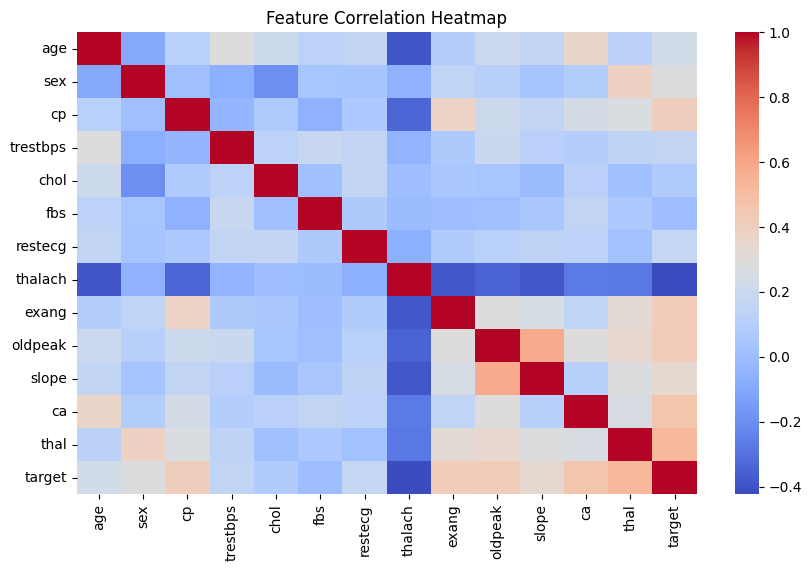

Accuracy: 0.8833333333333333
ROC AUC: 0.9467592592592592
Confusion Matrix:
 [[32  4]
 [ 3 21]]


In [2]:
print("--- 2. Tabular Data: UCI Cleveland Heart Disease ---")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=column_names, na_values="?")
df = df.dropna()
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


--- 3. Signal Data: MIT-BIH Arrhythmia Database ---


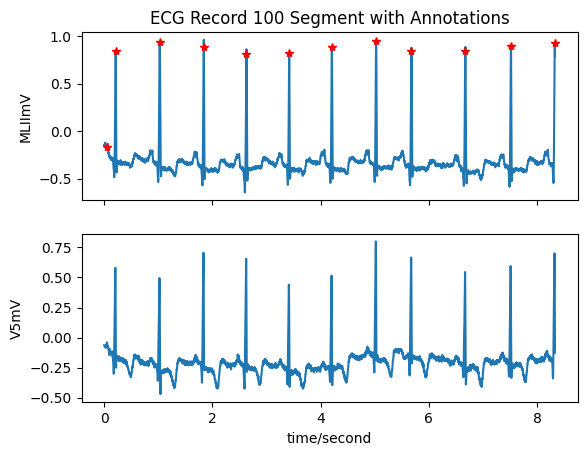

Mean RR Interval (samples): 270.90909090909093
Heart Rate Variability (Std Dev of RR intervals): 72.19097720686875


In [3]:
print("\n--- 3. Signal Data: MIT-BIH Arrhythmia Database ---")

record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3000)
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=3000)

wfdb.plot_wfdb(record=record, annotation=annotation,
               title='ECG Record 100 Segment with Annotations',
               time_units='seconds')

rr_intervals = np.diff(annotation.sample)
print("Mean RR Interval (samples):", np.mean(rr_intervals))
print("Heart Rate Variability (Std Dev of RR intervals):", np.std(rr_intervals))

In [7]:
print("\n--- 4. Textual Data Demonstration ---")

clinical_note = "Patient presents with severe chest pain and shortness of breath. History of hypertension. Resting ECG shows abnormalities."
print("Original Note:", clinical_note)

tokens = word_tokenize(clinical_note.lower())
stop_words = set(stopwords.words('english') + list(string.punctuation))

filtered_tokens = [word for word in tokens if word not in stop_words]
word_freq = Counter(filtered_tokens)

print("Key Terms and Frequencies:", word_freq.most_common(5))


--- 4. Textual Data Demonstration ---
Original Note: Patient presents with severe chest pain and shortness of breath. History of hypertension. Resting ECG shows abnormalities.
Key Terms and Frequencies: [('patient', 1), ('presents', 1), ('severe', 1), ('chest', 1), ('pain', 1)]



--- 5. Image Data Demonstration ---
Original Image Size: (400, 400)
Resized Image Size: (200, 200)


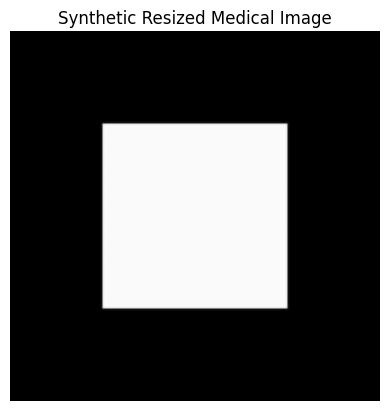

Image Format: JPEG
Image Mode: L


In [10]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("\n--- 5. Image Data Demonstration ---")

array = np.zeros((400, 400), dtype=np.uint8)
array[100:300, 100:300] = 180
temp_img = Image.fromarray(array)
temp_img.save("synthetic_scan.jpg", format="JPEG")

img = Image.open("synthetic_scan.jpg")
print("Original Image Size:", img.size)

resized_img = img.resize((200, 200))
print("Resized Image Size:", resized_img.size)

plt.imshow(resized_img, cmap='gray')
plt.axis('off')
plt.title("Synthetic Resized Medical Image")
plt.show()

print("Image Format:", img.format)
print("Image Mode:", img.mode)